# Mass-selected control: is luminosity selection adding anything?

Notebook 02 found that at fixed AGN number density, only `Omega_m` has a
real signal in the AGN kNN-CDF; every feedback parameter is consistent with
the null. One explanation: black holes sit at halo centers, so
luminosity-selected AGN positions are ~ halo positions, which `Omega_m` sets
and feedback largely doesn't. If that's right, **selecting by luminosity
isn't adding clustering information over just selecting the most massive
BHs** -- the AGN kNN-CDF would just be tracing host-halo-mass clustering.

This notebook runs the identical fixed-N pipeline with `tracer="mass"`
instead of the default luminosity ranking, at the **same N** as the AGN run
(read directly from its saved `.npz`, not re-typed), and compares.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src import config
from src.pipeline import run_suite
from src.params import load_params, align_to_params
from src.selection_bias import diagnose_retention_bias
from src.sensitivity import sensitivity_table, summary_dataframe, infer_layout

SIM_PATH = config.SIM_PATH
PARAMS_FILE = config.PARAMS_FILE
OUTPUT_DIR = config.OUTPUT_DIR

## 1. Load the AGN fixed-N run, read N_TARGET from it

Locked to whatever notebook 02 actually used -- never re-typed by hand, so
this notebook can't silently drift onto a different N than the run it's
meant to control for.

In [2]:
import glob

agn_candidates = sorted(glob.glob(f"{OUTPUT_DIR}/agn_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n*.npz"))
assert agn_candidates, (
    f"No AGN fixed-N run found in {OUTPUT_DIR} -- run notebook 02 first."
)
agn_path = agn_candidates[-1]
print("Using AGN run:", agn_path)

agn_data = np.load(agn_path, allow_pickle=True)
N_TARGET = int(agn_data["nbh"][0])
assert np.all(agn_data["nbh"] == N_TARGET), "AGN run is not fixed-N -- wrong file?"
print(f"N_TARGET = {N_TARGET} (from the AGN run's nbh)")

Using AGN run: ../outputs/agn_knn_snap50_M1e+06_n286.npz
N_TARGET = 286 (from the AGN run's nbh)


## 2. Generate the mass-selected control

Set `GENERATE = False` on re-runs once the `.npz` exists.

In [3]:
GENERATE = True

bhmass_path = f"{OUTPUT_DIR}/bhmass_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n{N_TARGET}.npz"

if GENERATE:
    result = run_suite(
        n_target=N_TARGET, tracer="mass",
        sim_path=SIM_PATH, output_dir=OUTPUT_DIR,
    )
else:
    data = np.load(bhmass_path, allow_pickle=True)
    result = {k: data[k] for k in ("sim_ids", "summaries", "nbh", "rgrid", "kvals")}

sim_ids = result["sim_ids"]
summaries = result["summaries"]
nbh = result["nbh"]
rgrid = result["rgrid"]
kvals = result["kvals"]
n_k, n_r = infer_layout(kvals, rgrid)

assert len(np.unique(nbh)) == 1 and nbh[0] == N_TARGET
print(f"{len(sim_ids)} simulations retained, {nbh[0]} BHs each (by mass), summary shape {summaries.shape}")

Found 1000 snapshots


100%|██████████| 1000/1000 [12:51<00:00,  1.30it/s]



Saved: ../outputs/bhmass_knn_snap50_M1e+06_n286.npz
Successful runs = 950 / 1000
Summary shape   = (950, 150)
N_AGN: mean 286.0, min 286, max 286
950 simulations retained, 286 BHs each (by mass), summary shape (950, 150)


## 3. Retention bias, sensitivity

Selecting by raw mass rather than luminosity should retain *at least* as
many simulations as the AGN run at the same N (the mass-eligible pool is a
superset of the luminosity-eligible one -- no finite/positive-luminosity
requirement), so retention bias should be no worse here.

In [4]:
theta_all = load_params(PARAMS_FILE)
theta = align_to_params(sim_ids, theta_all)
residuals = summaries - summaries.mean(axis=0)

all_ids = theta_all.index.to_numpy()
retention_diag = diagnose_retention_bias(sim_ids, all_ids, theta_all, params=config.ALL_PARAMS)
display(retention_diag)

print(f"retained: {len(sim_ids)} (mass) vs {len(agn_data['sim_ids'])} (AGN)")

,parameter,spearman_rho,spearman_p,ks_stat,ks_p,bias_flag
0,Omega_m,0.366541,3.704221e-33,0.046684,0.229419,True
1,sigma_8,0.189731,1.472567e-09,0.023632,0.940430,True
2,A_SN1,-0.024477,4.394099e-01,0.005947,1.000000,False
3,A_AGN1,0.028228,3.725414e-01,0.008158,1.000000,False
4,A_SN2,-0.015036,6.348473e-01,0.005158,1.000000,False
5,A_AGN2,-0.042120,1.832282e-01,0.005316,1.000000,False


retained: 950 (mass) vs 950 (AGN)


In [5]:
table_mass = sensitivity_table(
    residuals, theta,
    n_k=n_k, rgrid=rgrid, kvals=kvals,
    params=config.ALL_PARAMS,
    n_boot=2000, n_null=2000,
)
summary_mass = summary_dataframe(table_mass)
summary_mass.sort_values("R_obs", ascending=False)

,parameter,R_obs,ci_lo,ci_hi,null_floor,p_value,q_value,significant
0,Omega_m,0.019157,0.016845,0.021590,0.002873,0.0000,0.0000,True
2,A_SN1,0.004680,0.002339,0.007140,0.002861,0.0005,0.0015,True
1,sigma_8,0.003330,0.001055,0.006301,0.002916,0.0260,0.0520,False
4,A_SN2,0.001268,0.000697,0.004070,0.002859,0.4365,0.5448,False
3,A_AGN1,0.001256,0.000450,0.004180,0.002910,0.4540,0.5448,False
5,A_AGN2,0.000439,0.000424,0.003478,0.002817,0.9305,0.9305,False


## 4. Side-by-side comparison with the AGN run

Recomputes the AGN sensitivity table from its saved summaries (no abundance
removal needed -- same fixed-N reasoning as notebook 02) so both tables use
identical bootstrap/null settings.

In [6]:
agn_theta = align_to_params(agn_data["sim_ids"], theta_all)
agn_residuals = agn_data["summaries"] - agn_data["summaries"].mean(axis=0)
agn_n_k, agn_n_r = infer_layout(agn_data["kvals"], agn_data["rgrid"])

table_agn = sensitivity_table(
    agn_residuals, agn_theta,
    n_k=agn_n_k, rgrid=agn_data["rgrid"], kvals=agn_data["kvals"],
    params=config.ALL_PARAMS, n_boot=2000, n_null=2000,
)
summary_agn = summary_dataframe(table_agn)

comparison = (
    summary_agn.set_index("parameter")[["R_obs", "q_value"]].add_suffix("_agn")
    .join(summary_mass.set_index("parameter")[["R_obs", "q_value"]].add_suffix("_mass"))
)
comparison["ratio_mass_over_agn"] = comparison["R_obs_mass"] / comparison["R_obs_agn"]
comparison.sort_values("R_obs_agn", ascending=False)

,R_obs_agn,q_value_agn,R_obs_mass,q_value_mass,ratio_mass_over_agn
parameter,,,,,
Omega_m,0.020685,0.00000,0.019157,0.0000,0.926129
sigma_8,0.001879,0.61650,0.003330,0.0520,1.772667
A_SN2,0.001216,0.84675,0.001268,0.5448,1.043190
A_SN1,0.000970,0.84675,0.004680,0.0015,4.824731
A_AGN1,0.000470,0.91050,0.001256,0.5448,2.671432
A_AGN2,0.000464,0.91050,0.000439,0.9305,0.946231


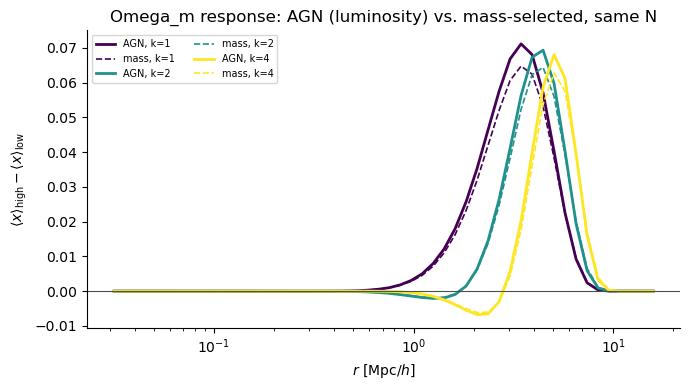

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

cmap = plt.get_cmap("viridis")
for ki in range(n_k):
    colour = cmap(ki / max(n_k - 1, 1))
    ax.plot(rgrid, table_agn["Omega_m"]["obs"][ki], color=colour, lw=2,
            label=f"AGN, k={kvals[ki]}")
    ax.plot(rgrid, table_mass["Omega_m"]["obs"][ki], color=colour, lw=1.2, ls="--",
            label=f"mass, k={kvals[ki]}")

ax.axhline(0, color="0.3", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"$r\ [\mathrm{Mpc}/h]$")
ax.set_ylabel(r"$\langle x\rangle_{\rm high} - \langle x\rangle_{\rm low}$")
ax.set_title("Omega_m response: AGN (luminosity) vs. mass-selected, same N")
ax.legend(fontsize=7, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## Reading this

If the two `Omega_m` curves nearly overlap and feedback stays null in both
tables, luminosity selection isn't adding clustering information beyond
black-hole (host-halo) mass at this N and snapshot -- the AGN kNN-CDF is
substantially a halo-mass-clustering statistic here. If the mass-selected
curve is meaningfully weaker or shaped differently, luminosity selection is
doing real work (e.g. picking out a more strongly-clustered, halo-mass-biased
sub-population than raw mass ranking would).